<a href="https://colab.research.google.com/github/kadamakanksha/End-to-End-Exploratory-Data-Analysis-EDA-on-the-Titanic-Dataset/blob/main/Intelligent_Document_Automation_Building_a_Smart_OCR_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("urbikn/sroie-datasetv2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.
Path to dataset files: /kaggle/input/sroie-datasetv2


In [ ]:
! cat /kaggle/input/sroie-datasetv2/SROIE2019/test/entities/X00016469670.txt

{
    "company": "OJC MARKETING SDN BHD",
    "date": "15/01/2019",
    "address": "NO 2 & 4, JALAN BAYU 4, BANDAR SERI ALAM, B1750 MASAI, JOHOR",
    "total": "193.00"
}

In [ ]:
! pip install opencv-python matplotlib numpy

In [ ]:
import os
one_image_path = os.path.join(path, 'SROIE2019', 'train', 'img', 'X51005453729.jpg')

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, title="Image"):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

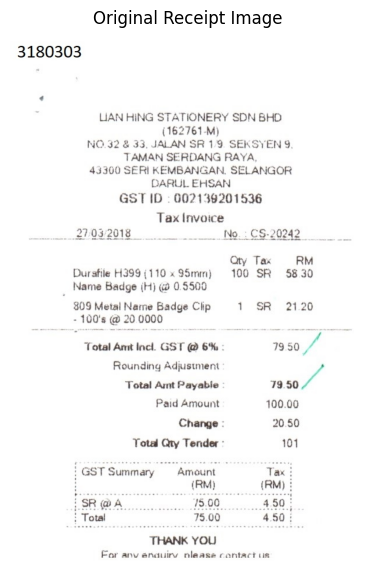

In [ ]:
one_image = cv2.imread(one_image_path)
display_image(one_image, "Original Receipt Image")

In [ ]:
# Convert the image to grayscale
def convert_to_grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

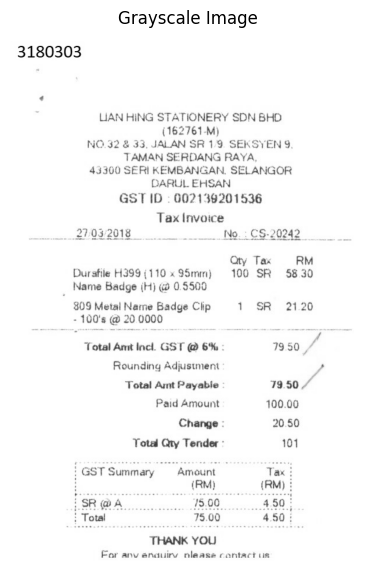

In [ ]:
grayscale_image = convert_to_grayscale(one_image)
display_image(grayscale_image, "Grayscale Image")

In [ ]:
def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

In [ ]:
def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, # Invert the colors (text becomes white because of matplotlib)
    11, # Block size
    4  # Constant C
  )

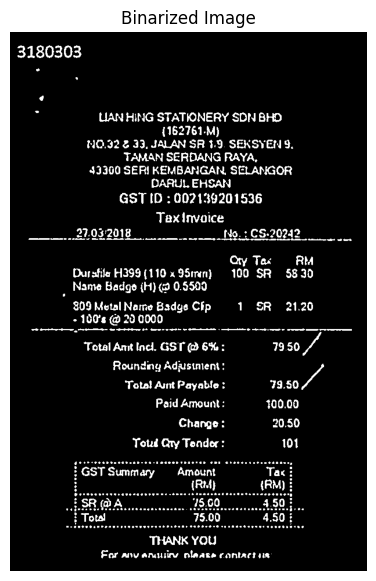

In [ ]:
blur_reduced_image = reduce_noise(grayscale_image)
binarized_image = binarize_image(blur_reduced_image)
display_image(binarized_image, "Binarized Image")

In [ ]:
import cv2
import numpy as np

def deskew_image(image):
    # 1. Prepare the image (Handling both Grayscale and Binary)
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # Invert the image if it's white background (SROIE usually is)
    # We need white text on black background for detection
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

    # 2. Dilate to merge text into lines
    # This helps the algorithm find the "baseline" of the text accurately
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    dilate = cv2.dilate(thresh, kernel, iterations=1)

    # 3. Find the largest contour (the main body of text)
    cnts = cv2.findContours(dilate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]

    if not cnts:
        return image

    largest_cnt = max(cnts, key=cv2.contourArea)

    # 4. Get the angle of the largest text block
    rect = cv2.minAreaRect(largest_cnt)
    angle = rect[-1]

    # OpenCV angle logic adjustment
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # 5. NO-OP Check: If the angle is tiny, don't perform rotation
    # This prevents blurring the image for no reason
    if abs(angle) < 0.5:
        return image

    # 6. Perform the Rotation
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, -angle, 1.0)

    # Use BORDER_REPLICATE to keep the edges looking natural
    deskewed = cv2.warpAffine(image, M, (w, h),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)

    return deskewed

In [ ]:
deskewed_image = deskew_image(binarized_image)

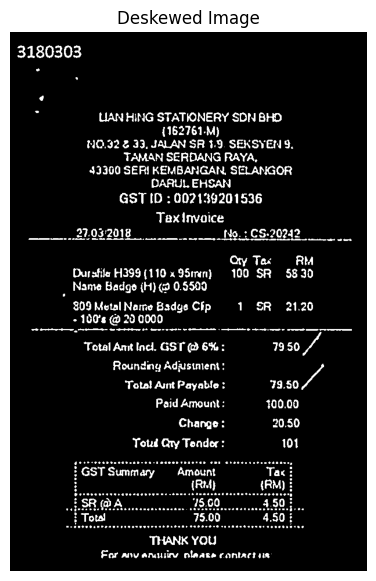

In [ ]:
display_image(deskewed_image, "Deskewed Image")

In [ ]:
import time
import os
import cv2 # Import opencv for image processing functions

output_folder_path = "/content/processed_images"
start_time = time.time()

# Define the image processing pipeline function
def process_one_image(image):
    grayscale = convert_to_grayscale(image)
    blurred = reduce_noise(grayscale)
    binarized = binarize_image(blurred)
    deskewed = deskew_image(binarized)
    return deskewed

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")


for image_name in os.listdir(os.path.join(path, 'SROIE2019', 'train', 'img'))[:20]:
  print(f"Processing image: {image_name}")
  image_path = os.path.join(path, 'SROIE2019', 'train', 'img', image_name)
  image = cv2.imread(image_path)
  processed_image = process_one_image(image)
  # save image
  output_path = os.path.join(output_folder_path, image_name)
  cv2.imwrite(output_path, processed_image)
  print(f"Saved processed image to: {output_path}")
  print("-"*50)

print("Processing images is completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Processing image: X51007231344.jpg
Saved processed image to: /content/processed_images/X51007231344.jpg
--------------------------------------------------
Processing image: X51005442344.jpg
Saved processed image to: /content/processed_images/X51005442344.jpg
--------------------------------------------------
Processing image: X51008142030.jpg
Saved processed image to: /content/processed_images/X51008142030.jpg
--------------------------------------------------
Processing image: X51005447853.jpg
Saved processed image to: /content/processed_images/X51005447853.jpg
--------------------------------------------------
Processing image: X51007339113.jpg
Saved processed image to: /content/processed_images/X51007339113.jpg
--------------------------------------------------
Processing image: X51005453729.jpg
Saved processed image to: /content/processed_images/X51005453729.jpg
--------------------------------------------------
Processing image: X51005763940.jpg
Saved processed image to: /content/

In [ ]:
! pip install pytesseract pillow

In [48]:
! sudo apt-get update
! sudo apt-get install tesseract-ocr

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 

In [ ]:
from PIL import Image
import pytesseract

print(pytesseract.image_to_string(Image.open('/content/processed_images/X51005711442.jpg')))

 

RESTORAN WAN SHENG
002043319-W
No.2, Jalan Temenggung 19/9,
Seksyen 9, Bandar Mahkota Cheras,
43200 Cheras, Selangor
GST REG NO; 001335787520

Tax Invoice

INV No.: 1047623 Cashier: Thandar
Date ; 16-03-2018 12:07:10

Kopi (B)

i. 2.20 Vays)
Teh (B)

1x 2,20 yay)
Cham (B)

ye 3 2.20 4.40 SR
DE) Acme VON

ee 0,20 0.80 SR
(open
ma eye-4 | a te om
GST payable (6%): 0.53
Total (Inclusive of GST); 9.60
TOTAL: 9.60
HS male

GST Summary Verne yD i
Sih (@ 6%) Ord 0

 

 

 



In [ ]:
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(input_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print("Extracting text from image..")
  text = pytesseract.image_to_string(Image.open(image_path))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".txt"))
  with open(output_path, "w") as f:
    f.write(text)

  print(f"Saved extracted text to {output_path}")
  print("-"*50)

print("Text Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 20
Processing image 1/20: X51005442344.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51005442344.txt
--------------------------------------------------
Processing image 2/20: X51008114283.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51008114283.txt
--------------------------------------------------
Processing image 3/20: X51005361897.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51005361897.txt
--------------------------------------------------
Processing image 4/20: X51008099044.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51008099044.txt
--------------------------------------------------
Processing image 5/20: X51007231344.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/X51007231344.txt
--------------------------------------------------
Processing image 6/20: X51005453729.jp

In [ ]:
prompt = """
Extract the information from the given image.
Information to be extracted: company, date, address, total.
The image has been converted to grayscale, noise reduced, binarized, and deskewed using opencv.
Always give your response in the following format:
{
    "company": "COMPANY_NAME",
    "date": "DATE",
    "address": "ADDRESS",
    "total": "TOTAL",
}
Also, the text has been extracted from the image using tesseract.
Use the extracted text as support for extracting information.
If you believe the text extraction is incorrect somewhere, you may correct it yourself and provide corrected information.
Respond with the extracted information only in the specified format.
Here is the text:


"""

In [ ]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [ ]:
genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))